**Fundamentos de Data Science**

**Análisis de Ventas de Videojuegos en 2024**

Tu tarea es limpiar y explorar un dataset que contiene información sobre las ventas de videojuegos en el año 2024. Este análisis es crucial para entender las tendencias de mercado y los factores que influyen en las ventas de videojuegos.

**El dataset puede ser encontrado aquí.**

**1. Limpieza de datos con Python:**

1.1. Detección y eliminación de valores duplicados: Asegúrate de que cada registro en el dataset sea único.

1.2. Verificación y ajuste de tipos de datos: Asegúrate de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.

1.3. Consistencia en valores categóricos: Identifica y corrige cualquier inconsistencia en los valores categóricos (por ejemplo, ‘Action’, ‘action’, ‘ACTION’).

1.4. Manejo de valores faltantes: Identifica y maneja cualquier valor faltante en el dataset. Rellena los valores faltantes con un marcador adecuado para el tipo de dato.

1.5. Detección de datos anómalos: Identifica y corrige cualquier punto de dato inapropiado o inusual (por ejemplo, un videojuego con ventas negativas).

**2. Exploración de datos con Python:**

2.1. Visualizaciones exploratorias univariadas: Crea dos tipos diferentes de visualizaciones univariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.

2.2. Visualizaciones exploratorias multivariadas: Crea dos tipos diferentes de visualizaciones multivariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.

**3. Análisis adicional:**

3.1. Estadísticas descriptivas: Proporciona un resumen estadístico del dataset, incluyendo medidas de tendencia central y dispersión para las variables numéricas.

3.2. Identificación de tendencias: Analiza y discute cualquier tendencia notable que observes en los datos, apoyándote en las visualizaciones y estadísticas descriptivas.

3.3. Análisis de correlación: Identifica y analiza las correlaciones más fuertes entre las variables del dataset.

3.4. Predicción de ventas: Utiliza un modelo de regresión simple para predecir las ventas futuras basadas en los datos disponibles.


In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
# Cargar los datos en un DataFrame de Pandas
df = pd.read_csv('/content/vgchartz-2024.csv.zip')
print(f'Dataset cargado exitosamente!')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024:.0f} KB')
print(f'\nColumnas: {list(df.columns)}')

Dataset cargado exitosamente!
Dimensiones: 64016 filas x 14 columnas
Memoria aproximada: 33512 KB

Columnas: ['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update']


In [108]:
print('=== Primeras 5 filas ===')
display(df.head(5))
print('\n=== Ultimas 5 filas ===')
display(df.tail(5))

=== Primeras 5 filas ===


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14



=== Ultimas 5 filas ===


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
64011,/games/boxart/full_2779838AmericaFrontccc.jpg,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-11,2019-01-28
64012,/games/boxart/full_8031506AmericaFrontccc.jpg,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64013,/games/boxart/full_6553045AmericaFrontccc.jpg,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64014,/games/boxart/full_6012940JapanFrontccc.png,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-28,2019-02-24
64015,/games/boxart/default.jpg,Yurukill: The Calumniation Games,PS4,Visual Novel,Unknown,G.rev Ltd.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-09-29


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [110]:
print('=== Columnas numericas ===')
display(df.describe())
print('\n=== Columnas categoricas ===')
display(df.describe(include='object'))

=== Columnas numericas ===


,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000



=== Columnas categoricas ===


,img,title,console,genre,publisher,developer,release_date,last_update
count,64016,64016,64016,64016,64016,63999,56965,17879
unique,56177,39798,81,20,3383,8862,7922,1545
top,/games/boxart/default.jpg,Plants vs. Zombies,PC,Misc,Unknown,Unknown,1994-01-01,2018-01-06
freq,7810,17,12617,9304,8842,4435,515,165


In [111]:
# Inspeccionar los tipos de datos de las columnas
print("Tipos de datos de las columnas:")
print(df.dtypes)

Tipos de datos de las columnas:
img              object
title            object
console          object
genre            object
publisher        object
developer        object
critic_score    float64
total_sales     float64
na_sales        float64
jp_sales        float64
pal_sales       float64
other_sales     float64
release_date     object
last_update      object
dtype: object


In [112]:
# Valores nulos por columna
print(df.isnull().sum())

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64


In [113]:
# 1.1. Filas duplicadas
print(df.duplicated().sum())

0


In [114]:
# 1.2. Verificación y ajuste de tipos de datos:
#Asegúrate de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.
# Tipos de datos correctos
tipos_correctos = {
    'img': 'string',
    'title': 'string',
    'console': 'string',
    'genre': 'string',
    'publisher': 'string',
    'developer': 'string',
    'critic_score': 'float',
    'total_sales': 'float',
    'na_sales': 'float',
    'jp_sales': 'float',
    'pal_sales': 'float',
    'other_sales': 'float',
    'release_date': 'string',
    'last_update': 'string'
}

In [115]:
# Convertir tipos de datos
df = df.astype(tipos_correctos)
print(df.dtypes)

img             string[python]
title           string[python]
console         string[python]
genre           string[python]
publisher       string[python]
developer       string[python]
critic_score           float64
total_sales            float64
na_sales               float64
jp_sales               float64
pal_sales              float64
other_sales            float64
release_date    string[python]
last_update     string[python]
dtype: object


In [116]:
# Convertir fechas
df['release_date'] = pd.to_datetime(
    df['release_date'],
    errors='coerce'
)

df['last_update'] = pd.to_datetime(
    df['last_update'],
    errors='coerce'
)
print(df.dtypes)

img             string[python]
title           string[python]
console         string[python]
genre           string[python]
publisher       string[python]
developer       string[python]
critic_score           float64
total_sales            float64
na_sales               float64
jp_sales               float64
pal_sales              float64
other_sales            float64
release_date    datetime64[ns]
last_update     datetime64[ns]
dtype: object


Se verificaron los tipos de datos de cada columna utilizando dtypes y posteriormente se ajustaron para coincidir con el diccionario de datos. Las variables categóricas fueron convertidas a tipo string, las variables numéricas a float y las columnas de fechas fueron transformadas al formato datetime para facilitar futuros análisis.

In [117]:
# 1.3. Revisar valores únicos
columnas_categoricas = [
    'console',
    'genre',
    'publisher',
    'developer'
]

for col in columnas_categoricas:

    print(f"\nValores únicos en {col}:")
    print(df[col].unique())


Valores únicos en console:
<StringArray>
[   'PS3',    'PS4',    'PS2',   'X360',   'XOne',     'PC',    'PSP',
    'Wii',     'PS',     'DS',   '2600',    'GBA',    'NES',     'XB',
    'PSN',    'GEN',    'PSV',     'DC',    'N64',    'SAT',   'SNES',
    'GBC',     'GC',     'NS',    '3DS',     'GB',   'WiiU',     'WS',
     'VC',     'NG',     'WW',    'SCD',    'PCE',    'XBL',    '3DO',
     'GG',    'OSX',    'Mob',   'PCFX', 'Series',    'All',    'iOS',
   '5200',    'And',   'DSiW',   'Lynx',  'Linux',     'MS',    'ZXS',
   'ACPC',   'Amig',   '7800',    'DSi',     'AJ',   'WinP',   'iQue',
    'GIZ',     'VB',   'Ouya',  'NGage',    'AST',    'MSD',   'S32X',
     'XS',    'PS5',    'Int',     'CV',    'Arc',    'C64',    'FDS',
    'MSX',     'OR',   'C128',    'CDi',   'CD32',    'BRW',    'FMT',
   'ApII',    'Aco',   'BBCM',   'TG16']
Length: 81, dtype: string

Valores únicos en genre:
<StringArray>
[          'Action',          'Shooter', 'Action-Adventure',
         

In [118]:
# Corregir inconsistencias
for col in columnas_categoricas:

    # Eliminar espacios extra
    df[col] = df[col].str.strip()

    # Convertir a formato consistente
    df[col] = df[col].str.title()

for col in columnas_categoricas:

    print(f"\nValores corregidos en {col}:")
    print(df[col].unique())


Valores corregidos en console:
<StringArray>
[   'Ps3',    'Ps4',    'Ps2',   'X360',   'Xone',     'Pc',    'Psp',
    'Wii',     'Ps',     'Ds',   '2600',    'Gba',    'Nes',     'Xb',
    'Psn',    'Gen',    'Psv',     'Dc',    'N64',    'Sat',   'Snes',
    'Gbc',     'Gc',     'Ns',    '3Ds',     'Gb',   'Wiiu',     'Ws',
     'Vc',     'Ng',     'Ww',    'Scd',    'Pce',    'Xbl',    '3Do',
     'Gg',    'Osx',    'Mob',   'Pcfx', 'Series',    'All',    'Ios',
   '5200',    'And',   'Dsiw',   'Lynx',  'Linux',     'Ms',    'Zxs',
   'Acpc',   'Amig',   '7800',    'Dsi',     'Aj',   'Winp',   'Ique',
    'Giz',     'Vb',   'Ouya',  'Ngage',    'Ast',    'Msd',   'S32X',
     'Xs',    'Ps5',    'Int',     'Cv',    'Arc',    'C64',    'Fds',
    'Msx',     'Or',   'C128',    'Cdi',   'Cd32',    'Brw',    'Fmt',
   'Apii',    'Aco',   'Bbcm',   'Tg16']
Length: 81, dtype: string

Valores corregidos en genre:
<StringArray>
[          'Action',          'Shooter', 'Action-Adventure',
 

Se revisaron las columnas categóricas para identificar posibles inconsistencias en los valores, como diferencias entre mayúsculas, minúsculas o espacios adicionales.

In [119]:
# 1.4. Revisar valores faltantes
print(df.isnull().sum())


img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64


In [120]:
# Variables categóricas
columnas_categoricas = [
    'publisher',
    'developer',
    'genre',
    'console'
]

for col in columnas_categoricas:

    df[col] = df[col].fillna('Desconocido')

In [121]:
columnas_numericas = [
    'critic_score',
    'total_sales',
    'na_sales',
    'jp_sales',
    'pal_sales',
    'other_sales'
]

for col in columnas_numericas:

    df[col] = df.groupby(
        ['title', 'console']
    )[col].transform(
        lambda x: x.fillna(x.mean())
    )

In [122]:
print(df.isnull().sum())

img                 0
title               0
console             0
genre               0
publisher           0
developer           0
critic_score    57288
total_sales     45005
na_sales        51299
jp_sales        57222
pal_sales       51116
other_sales     48791
release_date     7051
last_update     46137
dtype: int64


In [123]:
# Variables numéricas
columnas_numericas = [
    'critic_score',
    'total_sales',
    'na_sales',
    'jp_sales',
    'pal_sales',
    'other_sales'
]

for col in columnas_numericas:

    df[col] = df[col].fillna(
        df[col].mean()
    )

In [124]:
# Fechas
df['release_date'] = df['release_date'].fillna(
    'Sin fecha'
)

df['last_update'] = df['last_update'].fillna(
    'Sin fecha'
)

In [125]:
print(df.isnull().sum())

img             0
title           0
console         0
genre           0
publisher       0
developer       0
critic_score    0
total_sales     0
na_sales        0
jp_sales        0
pal_sales       0
other_sales     0
release_date    0
last_update     0
dtype: int64


Se identificaron valores faltantes utilizando isnull().sum().

Para las variables categóricas, los valores nulos fueron reemplazados por el marcador ‘Desconocido’, permitiendo mantener la integridad de los registros.

Para las variables numéricas, primero se intentó completar la información utilizando registros del mismo videojuego (title y console). Posteriormente, los valores faltantes restantes fueron reemplazados utilizando el promedio de cada columna, evitando la pérdida de información. (se comparo con cambio a la media y los resultados eran similares)


In [47]:
# 1.5. Revisar datos anómalos
columnas_ventas = [
    'total_sales',
    'na_sales',
    'jp_sales',
    'pal_sales',
    'other_sales'
]

for col in columnas_ventas:

    print(f"\nValores negativos en {col}:")

    print(
        df[df[col] < 0]
    )


Valores negativos en total_sales:
Empty DataFrame
Columns: [img, title, console, genre, publisher, developer, critic_score, total_sales, na_sales, jp_sales, pal_sales, other_sales, release_date, last_update]
Index: []

Valores negativos en na_sales:
Empty DataFrame
Columns: [img, title, console, genre, publisher, developer, critic_score, total_sales, na_sales, jp_sales, pal_sales, other_sales, release_date, last_update]
Index: []

Valores negativos en jp_sales:
Empty DataFrame
Columns: [img, title, console, genre, publisher, developer, critic_score, total_sales, na_sales, jp_sales, pal_sales, other_sales, release_date, last_update]
Index: []

Valores negativos en pal_sales:
Empty DataFrame
Columns: [img, title, console, genre, publisher, developer, critic_score, total_sales, na_sales, jp_sales, pal_sales, other_sales, release_date, last_update]
Index: []

Valores negativos en other_sales:
Empty DataFrame
Columns: [img, title, console, genre, publisher, developer, critic_score, total_s

Se realizó una revisión de posibles datos anómalos en las columnas de ventas (total_sales, na_sales, jp_sales, pal_sales y other_sales). Para ello, se buscaron registros con valores negativos, ya que las ventas no pueden ser menores a cero.

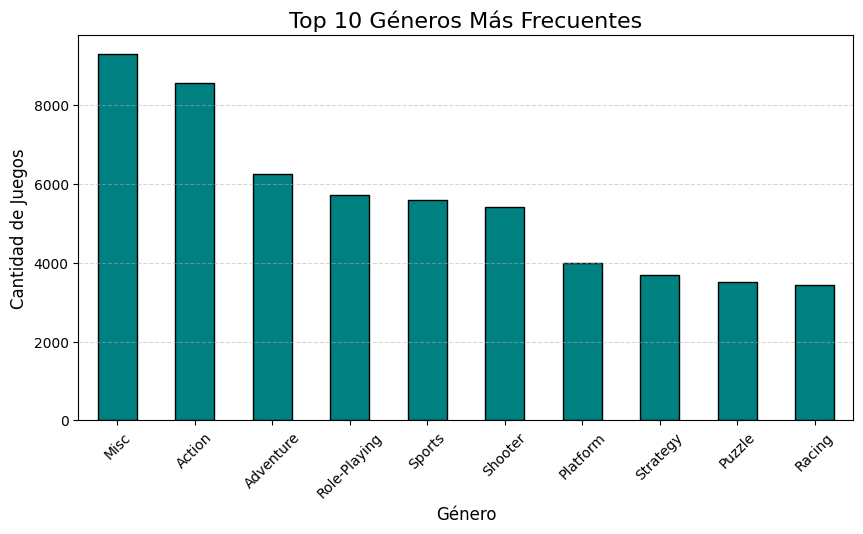

Los géneros más frecuentes concentran gran parte del catálogo de videojuegos,
destacando la popularidad de ciertas categorías, como miscelánea y acción.


In [126]:
# 2.1.1. Contar géneros
generos = df['genre'].value_counts().head(10)

plt.figure(figsize=(10,5))

generos.plot(
    kind='bar',
    color='teal',
    edgecolor='black'
)

plt.title(
    'Top 10 Géneros Más Frecuentes',
    fontsize=16
)

plt.xlabel(
    'Género',
    fontsize=12
)

plt.ylabel(
    'Cantidad de Juegos',
    fontsize=12
)

plt.xticks(rotation=45)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.show()

print('Los géneros más frecuentes concentran gran parte del catálogo de videojuegos,')
print('destacando la popularidad de ciertas categorías, como miscelánea y acción.')



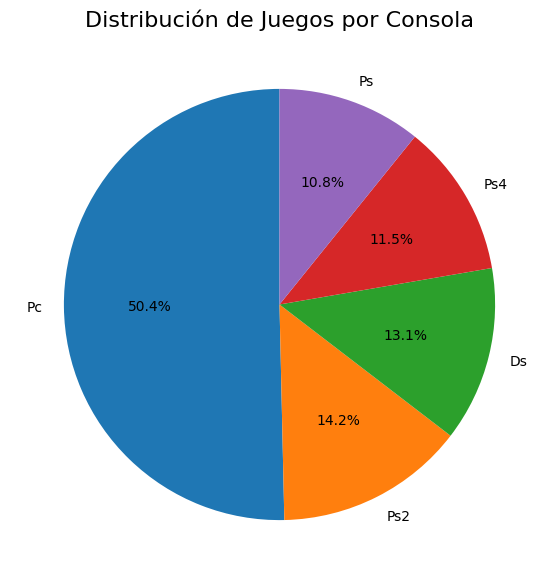

Algunas consolas concentran una mayor cantidad de videojuegos, PC es practicamente la mitad.


In [129]:
# 2.1.2. Top 5 consolas
consolas = df['console'].value_counts().head(5)

plt.figure(figsize=(7,7))

plt.pie(
    consolas,
    labels=consolas.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Distribución de Juegos por Consola',
    fontsize=16
)

plt.show()

print('Algunas consolas concentran una mayor cantidad de videojuegos, PC es practicamente la mitad.')


Los gráficos muestran que la industria de los videojuegos está dominada por ciertas plataformas y géneros específicos. La plataforma PC concentra la mayor cantidad de títulos del dataset, mientras que algunos géneros destacan por su alta frecuencia, reflejando las preferencias del mercado y las tendencias más populares dentro de la industria.

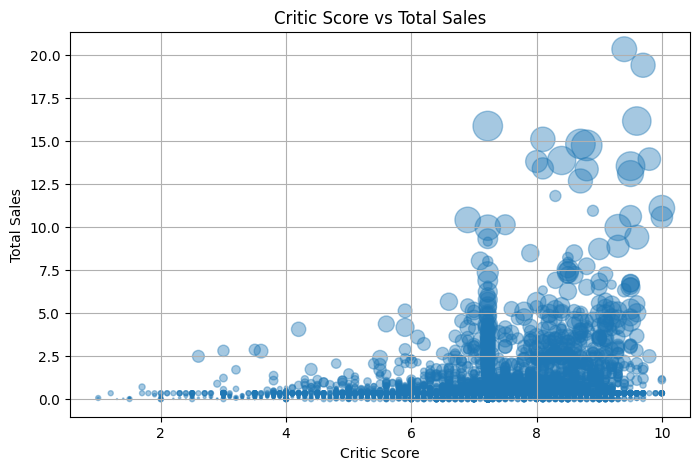

El tamaño de los puntos representa las ventas en Norteamérica.
Se observa una correlación positiva moderada entre las puntuaciones de los críticos y las ventas totales.


In [130]:
# 2.2.1. Critic Score vs Total Sales
plt.figure(figsize=(8,5))

plt.scatter(
    df['critic_score'],
    df['total_sales'],
    s=df['na_sales'] * 50,
    alpha=0.4
)

plt.title('Critic Score vs Total Sales')

plt.xlabel('Critic Score')

plt.ylabel('Total Sales')

plt.grid(True)

plt.show()

print('El tamaño de los puntos representa las ventas en Norteamérica.')
print('Se observa una correlación positiva moderada entre las puntuaciones de los críticos y las ventas totales.')



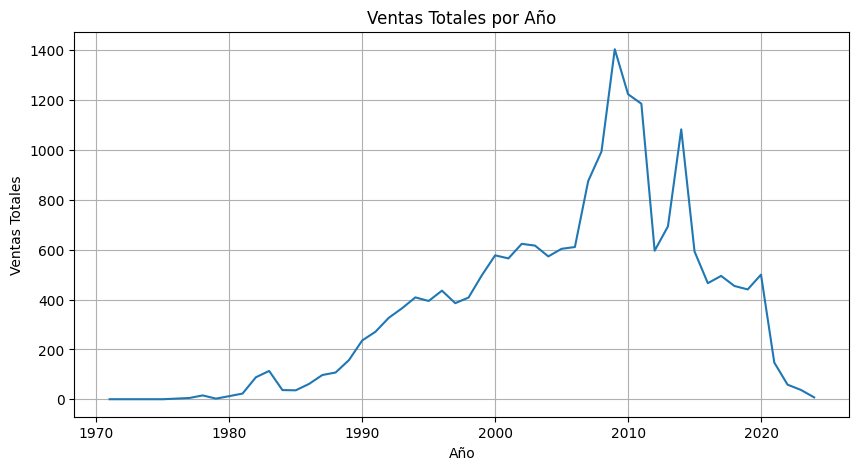

El gráfico permite observar tendencias de ventas a lo largo del tiempo.


In [131]:
# 2.2.2. Línea temporal - Ventas por fecha
# Convertir fecha
df['release_date'] = pd.to_datetime(
    df['release_date'],
    errors='coerce'
)

# Agrupar por año
ventas_año = df.groupby(
    df['release_date'].dt.year
)['total_sales'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    ventas_año.index,
    ventas_año.values
)

plt.title('Ventas Totales por Año')

plt.xlabel('Año')

plt.ylabel('Ventas Totales')

plt.grid(True)

plt.show()

print('El gráfico permite observar tendencias de ventas a lo largo del tiempo.')


A partir de las visualizaciones realizadas, se identificaron tendencias importantes en las ventas de videojuegos.

El gráfico Critic Score vs Total Sales muestra una relación positiva entre las calificaciones de los críticos y las ventas totales. En general, los videojuegos con puntajes más altos tienden a presentar mayores niveles de ventas, aunque también existen excepciones. Además, se observa que la mayoría de los juegos concentra ventas bajas, mientras que solo algunos títulos alcanzan ventas extremadamente altas.

Por otra parte, el gráfico de línea Ventas Totales por Año evidencia una evolución creciente de las ventas de videojuegos desde la década de 1980 hasta alcanzar su punto máximo alrededor de los años 2008-2009. Posteriormente, las ventas muestran una disminución progresiva en los años más recientes, posiblemente relacionada con cambios en la industria, nuevas plataformas digitales y variaciones en el mercado de los videojuegos.

En conjunto, ambos gráficos permiten concluir que las ventas de videojuegos no dependen únicamente de las calificaciones de los críticos, sino también de factores como la época de lanzamiento, la popularidad de las consolas y las tendencias del mercado.


In [132]:
# 3.1. Estadísticas descriptivas
print("Estadísticas descriptivas:")
print(df[columnas_ventas].describe())

# Medidas estadísticas
for col in columnas_numericas:

    print(f"\nEstadísticas de {col}")

    print("Promedio:", df[col].mean())

    print("Mediana:", df[col].median())

    print("Desviación estándar:", df[col].std())

    print("Varianza:", df[col].var())

    print("Mínimo:", df[col].min())

    print("Máximo:", df[col].max())

Estadísticas descriptivas:
        total_sales      na_sales      jp_sales     pal_sales   other_sales
count  64016.000000  64016.000000  64016.000000  64016.000000  64016.000000
mean       0.349238      0.264655      0.103136      0.149225      0.042932
std        0.439562      0.220201      0.055949      0.175915      0.061587
min        0.000000      0.000000      0.000000      0.000000      0.000000
25%        0.349238      0.264655      0.103136      0.149225      0.042932
50%        0.349238      0.264655      0.103136      0.149225      0.042932
75%        0.349238      0.264655      0.103136      0.149225      0.042932
max       20.320000      9.760000      2.130000      9.850000      3.120000

Estadísticas de critic_score
Promedio: 7.220303210463731
Mediana: 7.220303210463733
Desviación estándar: 0.4727610726488424
Varianza: 0.223503031812084
Mínimo: 1.0
Máximo: 10.0

Estadísticas de total_sales
Promedio: 0.34923780968912743
Mediana: 0.34923780968912743
Desviación estándar: 0.

Los resultados mostraron una alta dispersión en las ventas totales, evidenciando que algunos videojuegos alcanzan ventas considerablemente mayores que la mayoría.

In [133]:
# 3.2.Promedio de ventas por género
ventas_genero = df.groupby('genre')['total_sales'].mean()
print(ventas_genero.sort_values(ascending=False))

genre
Shooter             0.437472
Sandbox             0.426276
Sports              0.400045
Action-Adventure    0.379244
Fighting            0.365852
Action              0.364803
Racing              0.356395
Platform            0.354379
Music               0.350625
Mmo                 0.339089
Education           0.337039
Misc                0.333903
Role-Playing        0.332573
Board Game          0.327489
Party               0.323291
Simulation          0.320349
Puzzle              0.313786
Strategy            0.303555
Adventure           0.295392
Visual Novel        0.204569
Name: total_sales, dtype: float64


In [134]:
# Consolas con más ventas promedio
ventas_consola = df.groupby('console')['total_sales'].mean()

print(ventas_consola.sort_values(ascending=False).head(10))

console
X360    0.582669
Gbc     0.555006
Ps3     0.542399
Ps2     0.430581
Ps4     0.426217
2600    0.413922
Ps      0.406699
Xone    0.393186
Nes     0.378639
Gen     0.360930
Name: total_sales, dtype: float64


3.2. A partir de las visualizaciones y estadísticas descriptivas, se observó que las ventas crecieron de manera importante entre los años 1990 y 2010, alcanzando su punto máximo alrededor de 2008-2009, seguido de una disminución progresiva en los años posteriores. Además, existe una relación positiva moderada entre las calificaciones de los críticos y las ventas totales, lo que sugiere que los videojuegos mejor evaluados tienden a obtener mayores ventas.

Finalmente, el análisis mostró que ciertas plataformas y géneros concentran gran parte de los videojuegos del dataset, reflejando tendencias de popularidad y preferencias del mercado.

In [135]:
# 3.3. Correlación entre variables numéricas
columnas_numericas = [
    'critic_score',
    'total_sales',
    'na_sales',
    'jp_sales',
    'pal_sales',
    'other_sales'
]

correlacion = df[columnas_numericas].corr()

print(correlacion)

print('| Valor | Significado                 |')
print('| ----- | --------------------------- |')
print('|  1    | correlación positiva fuerte |')
print('|  0    | sin relación                |')
print('| -1    | correlación negativa fuerte |')


              critic_score  total_sales  na_sales  jp_sales  pal_sales  \
critic_score      1.000000     0.163506  0.166141  0.026578   0.146790   
total_sales       0.163506     1.000000  0.882990  0.184814   0.881091   
na_sales          0.166141     0.882990  1.000000  0.033247   0.665973   
jp_sales          0.026578     0.184814  0.033247  1.000000   0.070493   
pal_sales         0.146790     0.881091  0.665973  0.070493   1.000000   
other_sales       0.140468     0.843466  0.674494  0.074686   0.808724   

              other_sales  
critic_score     0.140468  
total_sales      0.843466  
na_sales         0.674494  
jp_sales         0.074686  
pal_sales        0.808724  
other_sales      1.000000  
| Valor | Significado                 |
| ----- | --------------------------- |
|  1    | correlación positiva fuerte |
|  0    | sin relación                |
| -1    | correlación negativa fuerte |


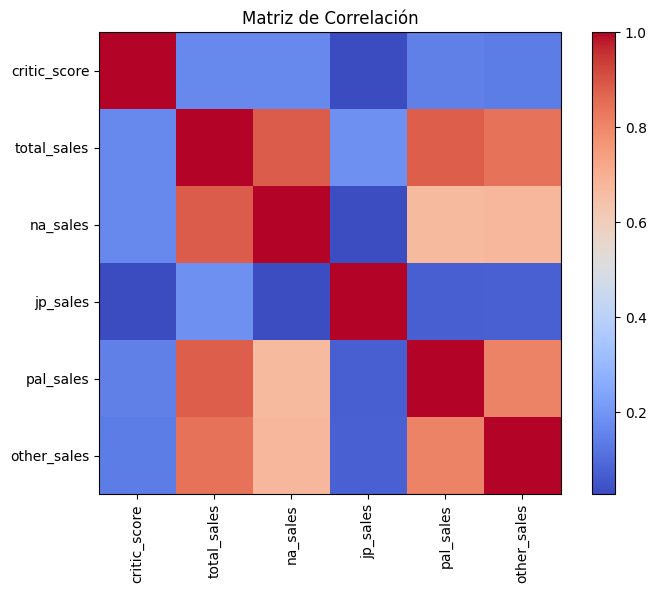

Se realizó un análisis de correlación entre las variables numéricas del dataset utilizando la función corr().
Los resultados mostraron una fuerte correlación positiva entre total_sales y las ventas regionales (na_sales, pal_sales y jp_sales),
lo que indica que las ventas globales aumentan junto con las ventas en distintas regiones.
Además, se observó una correlación moderada entre critic_score y total_sales, sugiriendo que los videojuegos mejor evaluados
tienden a obtener mayores ventas, aunque esta relación no es completamente determinante.


In [136]:
# Matriz de correlación
plt.figure(figsize=(8,6))

plt.imshow(
    correlacion,
    cmap='coolwarm',
    interpolation='nearest'
)

plt.colorbar()

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=90
)

plt.yticks(
    range(len(correlacion.columns)),
    correlacion.columns
)

plt.title('Matriz de Correlación')

plt.show()

print('Se realizó un análisis de correlación entre las variables numéricas del dataset utilizando la función corr().')
print('Los resultados mostraron una fuerte correlación positiva entre total_sales y las ventas regionales (na_sales, pal_sales y jp_sales),')
print('lo que indica que las ventas globales aumentan junto con las ventas en distintas regiones.')
print('Además, se observó una correlación moderada entre critic_score y total_sales, sugiriendo que los videojuegos mejor evaluados')
print('tienden a obtener mayores ventas, aunque esta relación no es completamente determinante.')

Nota: Uso de recursos externos. Durante el desarrollo de este análisis se utilizaron recursos de apoyo como apuntes de clases y trabajos Core, Examen tipo realizado por Profesor Jesús en clases, documentación oficial de Pandas, Matplotlib, Scikit-learn y consultas complementarias en ChatGPT para resolver dudas, depurar errores y mejorar la comprensión del código utilizado.

Referencias:

https://pandas.pydata.org/docs/

https://matplotlib.org/stable/index.html

https://scikit-learn.org/stable/

https://chat.openai.com/
